# Window Score Sandbox (Inside/Outside)

This notebook lets you **manually choose an "inside" subset** (one or more index ranges) and compute the **same normalized score** used in your scan code:

\[
\text{score} \,=\, 1 - \frac{\mathrm{SSE}_{\text{in}} + \mathrm{SSE}_{\text{out}}}{\mathrm{SSE}_{\text{all}}}
\]

It supports:
- **Gaussian NWKR** (inside and complement SSE via `gaussian_state_init`)
- **Laplace NWKR** (inside SSE via `laplace_sri`, outside via your `laplace_sro_nearband`)

Notes:
- This reproduces your scan/benchmark score path.
- You can plug in any `x` and `freqs` arrays (see “Load data” cell).


In [17]:
import numpy as np
import pandas as pd

# --- CosmicAI imports (must be available in your environment) ---
from cosmicai.config import ref_freq, set_kernel_kind, KernelKind
from cosmicai.kernels import get_kernel_and_denom
from cosmicai.gaussian_state import gaussian_state_init
from cosmicai.scoring import (
    calculate_gaussian_sra_with_nd,
    laplace_sri,
    laplace_sro_nearband,
)
from cosmicai.laplace_fast import calculate_laplace_sra_fast
from cosmicai.predictors import predict_on_idxs


In [34]:
def make_inside_idxs(ranges, n: int) -> np.ndarray:
    """
    Convert a list of inclusive ranges [(a,b), ...] into a sorted unique idx array.
    """
    if ranges is None:
        return np.array([], dtype=np.int64)
    idxs = []
    for (a, b) in ranges:
        a = int(a); b = int(b)
        if b < a:
            continue
        a = max(0, a); b = min(n - 1, b)
        idxs.append(np.arange(a, b + 1, dtype=np.int64))
    if not idxs:
        return np.array([], dtype=np.int64)
    out = np.concatenate(idxs)
    out = np.unique(out)
    return out.astype(np.int64)


def complement_idxs(inside: np.ndarray, n: int) -> np.ndarray:
    """
    Complement [0..n-1] \ inside, assuming inside is sorted unique int64.
    """
    all_idx = np.arange(n, dtype=np.int64)
    if inside.size == 0:
        return all_idx
    return np.setdiff1d(all_idx, inside, assume_unique=True).astype(np.int64)


def window_physical_width(freqs: np.ndarray, inside: np.ndarray) -> float:
    """
    If inside is a single contiguous interval, return f[max]-f[min].
    Otherwise return NaN.
    """
    if inside.size == 0:
        return float("nan")
    diffs = np.diff(inside)
    if diffs.size == 0 or np.all(diffs == 1):
        return float(freqs[int(inside[0])] - freqs[int(inside[-1])])
    return float("nan")


In [19]:
# ------------------------
# Load data
# ------------------------

data_path = "Data/QA2_Bandpass_Data_Labeled.parquet"
df = pd.read_parquet(data_path)

In [28]:
df_filtered = df.iloc[71722]

x = df_filtered.amplitude.astype(np.float64)
freq_array = df_filtered.frequency_array.astype(np.float64) / 1e9
y = np.arange(len(df_filtered.frequency_array))

In [58]:
def compute_window_score(
    x: np.ndarray,
    y: np.ndarray,
    freq_array: np.ndarray,
    inside_ranges,
    *,
    kernel_kind: str = "gaussian",     # "gaussian" or "laplace"
    buffer: int = 0,
    w_override: int | None = None,
    range_cap_override: int | None = None,
):
    """
    Compute (sra, sri, sro, score) for a user-chosen inside subset.

    This matches scan_row_with_nwkr normalization:
        score = 1 - (sri + sro)/sra
    """
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    n = x.size
    assert y.size == n, "freqs must match x length"

    # Trim like scan_row_with_nwkr (optional)
    if buffer > 0:
        x_use = x[buffer: n - buffer]
        freqs_use = freq_array[buffer: n - buffer]
    else:
        x_use = x
        freqs_use = freq_array

    n_use = x_use.size
    if n_use <= 0:
        raise ValueError("After trimming, signal is empty. Reduce buffer.")

    # Auto hyperparameters (same structure as your scan code)
    freq_step = abs(freqs_use[1] - freqs_use[0])
    L = int(freqs_use.size)
    R = float(ref_freq) / (freq_step if freq_step > 0 else 1.0)

    w_auto = int(round(max(3, min(R, L / 16))))
    range_cap_auto = 3 * w_auto

    # w = int(w_override) if (w_override is not None and int(w_override) > 0) else w_auto
    w = 3
    w_in = w // 3
    # range_cap = int(range_cap_override) if (range_cap_override is not None and int(range_cap_override) > 0) else range_cap_auto
    range_cap = 9

    # Inside subset (in trimmed coordinates)
    inside = make_inside_idxs(inside_ranges, n_use)
    outside = complement_idxs(inside, n_use)

    if inside.size == 0:
        raise ValueError("Inside subset is empty. Provide at least one (a,b) range.")

    # Set kernel kind globally (matches your config usage)
    if kernel_kind.lower().startswith("gauss"):
        set_kernel_kind("gaussian")
        kkind = KernelKind.GAUSSIAN
    elif kernel_kind.lower().startswith("lap"):
        set_kernel_kind("laplace")
        kkind = KernelKind.LAPLACE
    else:
        raise ValueError("kernel_kind must be 'gaussian' or 'laplace'")

    # --- Compute SRA, then SRI/SRO for the chosen split ---
    if kkind == KernelKind.GAUSSIAN:
        W, denom_cached = get_kernel_and_denom(n_use, w, KernelKind.GAUSSIAN)
        sra, _, pred_all, numer_all, denom_all, _ = calculate_gaussian_sra_with_nd(
            x_use, W, denom_cached
        )
        sra = float(max(sra, 1e-12))

        W_in, _ = get_kernel_and_denom(n_use, w_in, KernelKind.GAUSSIAN)

        in_idxs, in_num, in_den, sri = gaussian_state_init(x_use, inside, W)

        pred_in = np.zeros(n_use, dtype=np.float64)
        for k, i in enumerate(in_idxs):
            if in_den[k] > 1e-12:
                pred_in[i] = in_num[k] / in_den[k]
        
        out_idxs, out_num, out_den, sro = gaussian_state_init(x_use, outside, W)

        pred_out = np.zeros(n_use, dtype=np.float64)
        for k, i in enumerate(out_idxs):
            if out_den[k] > 1e-12:
                pred_out[i] = out_num[k] / out_den[k]

    else:
        sigma = float(max(w, 1))
        sigma_in = w // 2
        sra, _, pred_all, ssr_ps = calculate_laplace_sra_fast(x_use, sigma)
        sra = float(max(sra, 1e-12))

        # Mirror your scan path for Laplace:
        a0 = int(inside[0])
        b0 = int(inside[-1])
        sri = float(laplace_sri(x_use, inside, a0, b0, sigma))
        sro = float(laplace_sro_nearband(x_use, outside, a0, b0, range_cap, ssr_ps, sigma))

        pred_in = np.zeros(n_use, dtype=np.float64)
        pred_in[inside] = predict_on_idxs(
            x_use, inside, None, KernelKind.LAPLACE, sigma
        )

        pred_out = np.zeros(n_use, dtype=np.float64)
        pred_out[outside] = predict_on_idxs(
            x_use, outside, None, KernelKind.LAPLACE, sigma
        )

    score = 1.0 - float((sri + sro) / sra)
    width = window_physical_width(freqs_use, inside)

    return {
        "kernel_kind": kernel_kind,
        "n": int(n_use),
        "w_used": int(w),
        "range_cap_used": int(range_cap),
        "inside_ranges": inside_ranges,
        "inside_idxs": inside,
        "outside_idxs": outside,
        "sra": float(sra),
        "sri": float(sri),
        "sro": float(sro),
        "score": float(score),
        "contiguous_width": float(width),
        "freq_step_est": float(freq_step),
        "R_est": float(R),
        "pred_all": pred_all,
        "pred_in": pred_in,
        "pred_out": pred_out if "pred_out" in locals() else None,
    }


In [60]:
# ------------------------
# Choose your inside ranges here (inclusive indices)
# ------------------------
inside_ranges = [(1480, 1530)]
# inside_ranges = [(10, 20), (40, 55)]

kernel_kind = "gaussian"

out = compute_window_score(
    x, y, freq_array, inside_ranges,
    kernel_kind=kernel_kind,
    buffer=0,
)

for k in ["kernel_kind","n","w_used","range_cap_used","sra","sri","sro","score","contiguous_width","freq_step_est","R_est"]:
    print(f"{k:>16s} : {out[k]}")

print("\nInside size:", out["inside_idxs"].size, "Outside size:", out["outside_idxs"].size)


     kernel_kind : gaussian
               n : 1920
          w_used : 3
  range_cap_used : 9
             sra : 0.0015234064915496614
             sri : 2.8638729163671086e-05
             sro : 0.0014979903326527788
           score : -0.002115371231949048
contiguous_width : 0.048828125
   freq_step_est : 0.0009765625
           R_est : 64.0

Inside size: 51 Outside size: 1869


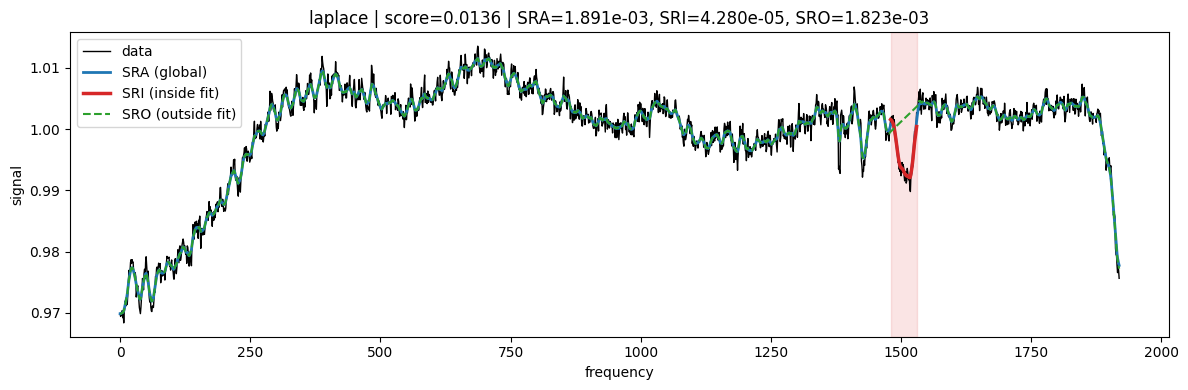

In [57]:
# Optional visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Raw signal
plt.plot(y, x, color="black", linewidth=1.0, label="data")

# Global fit (SRA)
plt.plot(y, out["pred_all"], color="C0", linewidth=2.0, label="SRA (global)")

# Inside-only fit
inside = out["inside_idxs"]
plt.plot(
    y[inside],
    out["pred_in"][inside],
    color="C3",
    linewidth=2.5,
    label="SRI (inside fit)",
)

# Optional outside-only fit
if out.get("pred_out") is not None:
    outside = out["outside_idxs"]
    plt.plot(
        y[outside],
        out["pred_out"][outside],
        color="C2",
        linewidth=1.5,
        linestyle="--",
        label="SRO (outside fit)",
    )

# Shade inside window
if inside.size:
    a, b = int(inside[0]), int(inside[-1])
    plt.axvspan(y[a], y[b], color="C3", alpha=0.12)

plt.title(
    f"{out['kernel_kind']} | score={out['score']:.4f} | "
    f"SRA={out['sra']:.3e}, SRI={out['sri']:.3e}, SRO={out['sro']:.3e}"
)
plt.xlabel("frequency")
plt.ylabel("signal")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

